In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 07 · Signals and cost-aware backtest (development out-of-fold)
Signal at bar close, execution at the next bar's VWAP, staggered 15-minute holding, fees + slippage + half spread, funding charged at settlement.

In [2]:
json.loads((T / 'primary_model_selection.json').read_text())

{'rule': 'lowest mean validation log loss, feature set E_all, h=15',
 'candidates': [{'config': 'rf_E_all_h15',
   'log_loss_mean': 0.6910792730603974,
   'auc_mean': 0.5380546436319827,
   'auc_sd': 0.008704909231549342},
  {'config': 'lgbm_E_all_h15',
   'log_loss_mean': 0.6911252929485833,
   'auc_mean': 0.5387774537232121,
   'auc_sd': 0.0083776960052558},
  {'config': 'logit_E_all_h15',
   'log_loss_mean': 0.6916694555963788,
   'auc_mean': 0.5366560170441984,
   'auc_sd': 0.008137584365079388}],
 'selected': 'rf_E_all_h15',
 'delta_rule': 'highest out-of-fold net Sharpe at base cost',
 'delta_selected': 0.05,
 'delta_table': [{'delta': 0.005,
   'active_share': 0.909698234503934,
   'sharpe_base': -24.514731692727498,
   'total_return_base': -0.9999999966501272,
   'sharpe_gross': 1.2735146404314572,
   'sum_gross': 1.1113688506420776,
   'breakeven_bps': 0.2964509365129117,
   'n_trades': 758470,
   'turnover_per_day': 63.78422567645365},
  {'delta': 0.01,
   'active_share': 0.8

In [3]:
tab(T / 'dev_delta_selection.csv')

delta,active_share,sharpe_base,total_return_base,sharpe_gross,sum_gross,breakeven_bps,n_trades,turnover_per_day
f64,f64,f64,f64,f64,f64,f64,i64,f64
0.005,0.909698,-24.514732,-1.0,1.273515,1.111369,0.296451,758470,63.784226
0.01,0.820837,-24.269669,-1.0,1.288746,1.107386,0.30125,684381,62.599194
0.02,0.650128,-23.587949,-1.0,1.294772,1.036832,0.305571,542051,57.866667
0.03,0.497179,-22.118453,-1.0,1.527556,1.097155,0.370042,414528,50.69384
0.05,0.260946,-17.81894,-0.999931,2.092124,1.107398,0.573171,217566,33.086241


In [4]:
tab(T / 'dev_backtest_summary.csv', ['strategy','cost','total_return','sharpe','max_drawdown','n_trades','win_rate','avg_trade_bps','breakeven_cost_bps_per_side','turnover_per_day'])

strategy,cost,total_return,sharpe,max_drawdown,n_trades,win_rate,avg_trade_bps,breakeven_cost_bps_per_side,turnover_per_day
str,str,f64,f64,f64,i64,f64,f64,f64,f64
"""ml""","""gross""",1.731736,2.092124,-0.28988,217566,0.560262,0.764654,0.573171,33.086241
"""momentum""","""gross""",-0.797791,-1.779738,-0.83055,833147,0.478451,-0.251657,-0.247194,99.503166
"""flow_rule""","""gross""",-0.591546,-1.907482,-0.661322,278576,0.474359,-0.451194,-0.273963,53.066321
"""random""","""gross""",-0.102161,-0.664582,-0.171865,216795,0.498568,-0.072656,-0.040429,43.458492
"""buy_and_hold""","""gross""",0.045989,0.317213,-0.69362,1,NaN,NaN,3556.243385,0.001727
"""ml""","""low""",-0.978255,-7.10308,-0.978917,217566,0.484777,-4.281346,0.573171,33.086241
"""momentum""","""low""",-1.0,-19.136286,-1.0,833147,0.392802,-5.297657,-0.247194,99.503166
"""flow_rule""","""low""",-0.999824,-18.799731,-0.999826,278576,0.384674,-5.497194,-0.273963,53.066321
"""random""","""low""",-0.998429,-41.755162,-0.998435,216795,0.411799,-5.118656,-0.040429,43.458492


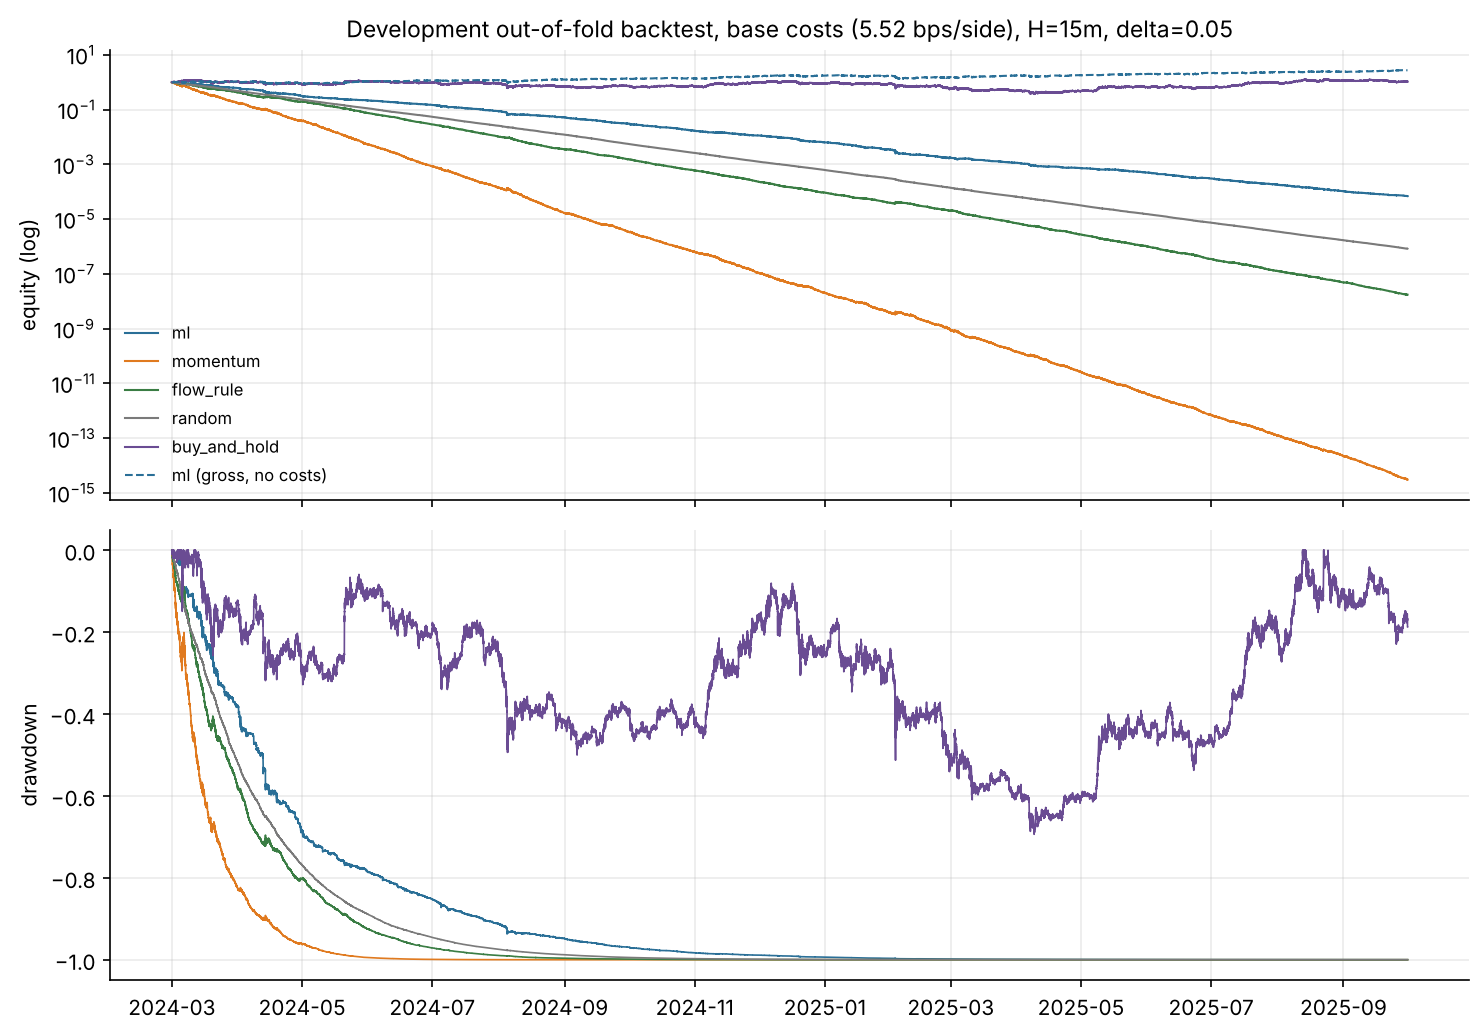

In [5]:
show(F / 'dev/dev_equity_drawdown.png')

In [6]:
tab(T / 'dev_regimes.csv')

regime,cost,minutes,auc,sum_net,mean_net_bps_per_min,turnover
str,str,i64,f64,f64,f64,f64
"""1_low""","""base""",52111,0.546002,-0.611971,-0.117436,1062.8
"""2_mid""","""base""",165330,0.534685,-2.149612,-0.13002,3749.6
"""3_high""","""base""",616319,0.53611,-6.720772,-0.109047,14344.533333
"""1_low""","""gross""",52111,0.546002,-0.024987,-0.004795,1062.8
"""2_mid""","""gross""",165330,0.534685,-0.078708,-0.004761,3749.6
"""3_high""","""gross""",616319,0.53611,1.201714,0.019498,14344.533333
